In [ ]:
from google.colab import files
uploaded = files.upload()

Saving eda.csv to eda.csv


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('eda.csv')
df

,umur,jenis_kelamin,pekerjaan,gaji,is_menikah,berat,tinggi,is_merokok,pendidikan,ever_stress
0,27.0,Perempuan,PNS,7.957453e+06,1.0,54.315053,170.428542,1.0,S1,1
1,53.0,Perempuan,PNS,7.633003e+06,1.0,72.873404,165.530097,0.0,S1,1
2,37.0,Perempuan,Pegawai swasta,6.637625e+06,1.0,46.321533,154.599388,0.0,S1,1
3,36.0,Perempuan,Pengangguran,3.624871e+06,1.0,51.539781,167.340481,1.0,SD,1
4,38.0,Laki-laki,Freelance,6.031808e+06,1.0,60.726909,165.514773,1.0,S2,0
...,...,...,...,...,...,...,...,...,...,...
7912,32.0,Laki-laki,Pegawai swasta,6.024409e+06,1.0,44.432438,154.578859,0.0,SMA,1
7913,34.0,Laki-laki,Pegawai swasta,1.007043e+07,1.0,49.389914,158.782726,1.0,S1,1
7914,58.0,Laki-laki,Freelance,8.010815e+06,1.0,54.351968,154.478087,1.0,S2,1
7915,30.0,NaN,PNS,9.059906e+06,1.0,57.646930,163.377717,0.0,S1,1


In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7917 entries, 0 to 7916
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   umur           7838 non-null   float64
 1   jenis_kelamin  7840 non-null   object 
 2   pekerjaan      7760 non-null   object 
 3   gaji           7843 non-null   float64
 4   is_menikah     7845 non-null   float64
 5   berat          7861 non-null   float64
 6   tinggi         7843 non-null   float64
 7   is_merokok     7847 non-null   float64
 8   pendidikan     7847 non-null   object 
 9   ever_stress    7917 non-null   int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 618.6+ KB


In [ ]:
df.describe()

,umur,gaji,is_menikah,berat,tinggi,is_merokok,ever_stress
count,7838.000000,7.843000e+03,7845.000000,7861.000000,7843.000000,7847.000000,7917.000000
mean,39.461725,8.853770e+06,0.979095,55.957306,167.252704,0.497133,0.700392
std,9.942286,4.499844e+06,0.143076,9.594065,10.933646,0.500024,0.458115
min,-1.000000,1.500000e+06,0.000000,40.000000,125.491784,0.000000,0.000000
25%,33.000000,5.735468e+06,1.000000,49.312715,159.758874,0.000000,0.000000
50%,39.000000,7.850662e+06,1.000000,53.839669,167.155287,0.000000,1.000000
75%,46.000000,1.083589e+07,1.000000,60.259654,174.439620,1.000000,1.000000
max,77.000000,5.000000e+07,1.000000,150.000000,226.454577,1.000000,1.000000


In [ ]:
df.describe(include=[object])

,jenis_kelamin,pekerjaan,pendidikan
count,7840,7760,7847
unique,2,4,6
top,Laki-laki,Pegawai swasta,S1
freq,5367,3160,4309


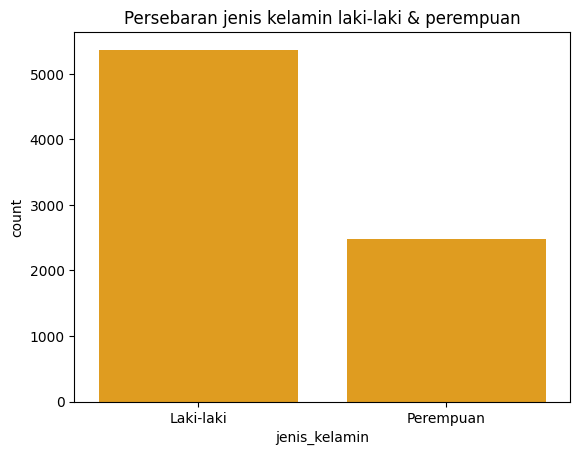

In [ ]:
sns.barplot(df.jenis_kelamin.value_counts().reset_index(), x='jenis_kelamin', y='count', color='orange')
plt.title('Persebaran jenis kelamin laki-laki & perempuan')
plt.show()

#kesimpulan
dari data di atas jumlah laki-laki dan perempuan lebih banyak dibangingkan dengan jumlah perempuan

/tmp/ipython-input-228078535.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=mean_df, y='jenis_kelamin', x='gaji', palette='Set2', ci=None)
/tmp/ipython-input-228078535.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=mean_df, y='jenis_kelamin', x='gaji', palette='Set2', ci=None)


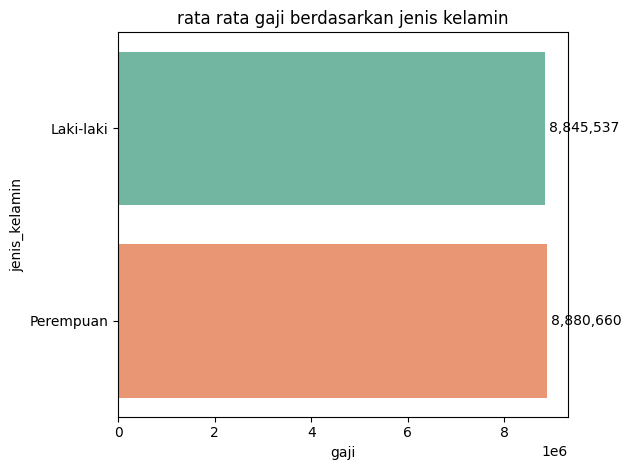

In [ ]:
#explorasi bivariet
mean_df = df.groupby('jenis_kelamin')['gaji'].mean().reset_index()
ax = sns.barplot(data=mean_df, y='jenis_kelamin', x='gaji', palette='Set2', ci=None)
plt.title('rata rata gaji berdasarkan jenis kelamin')
x_max = ax.get_xlim()[1]
for p in ax.patches:
    width = p.get_width()
    ax.text(width + x_max*0.01, p.get_y() + p.get_height()/2, f'{width:,.0f}', va='center')
plt.tight_layout()
plt.show()

#kesimpulan..
rata-rata gaji laki-laki dan perempuan ternyata lebih tinggi gaji perempuan dibandingkan rata-rata gaji laki dengan perbedaan yg tidak jauh.

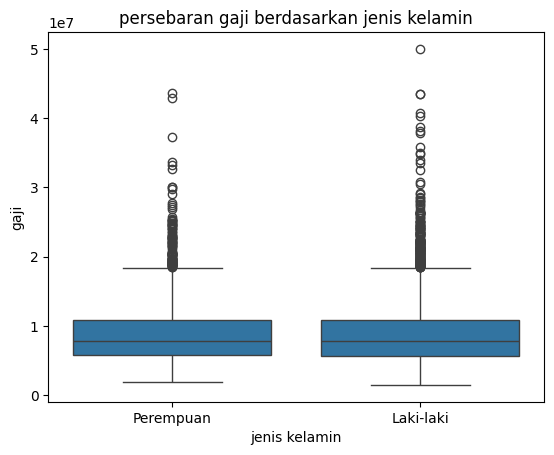

In [ ]:
#ppengaruh jenis kelamin terhadap gaji
sns.boxplot(data=df, x='jenis_kelamin', y='gaji')
plt.title('persebaran gaji berdasarkan jenis kelamin')
plt.xlabel('jenis kelamin')
plt.ylabel('gaji')
plt.show()

#kesimpilan
1. secara umum besara gaji dan perempuan identik sama walaupun dari segi outlier laki laki ada beberapa yg mendapatkan gaji leboh tinggi
2. secara median antara gaji laki laki dan perempuan hampir sama artinya tidak memiliki perbedaan yg signifikan.
3. tidak ada pengaruh jenis kelamin terhadap gai.

In [ ]:
bins = [0, 25, 35, 45, 55, 65, 100]  # batas usia
labels = ['<25', '26-35', '36-45', '46-55', '56-65', '>65']
df['rentang_usia'] = pd.cut(df['umur'], bins=bins, labels=labels, right=True)
usia_counts = df['rentang_usia'].value_counts().sort_index().reset_index()
usia_counts.columns = ['rentang_usia', 'count']
usia_counts

,rentang_usia,count
0,<25,619
1,26-35,2064
2,36-45,3024
3,46-55,1711
4,56-65,377
5,>65,37


#kesimpulan
dari data rentan usia pegawai ternyata paling tinggi berada pada usia 36-45 sebanyak 3.024 pegawai

In [ ]:
len(df)

7917

In [ ]:
#perbandingan jumlah pegawai yang sudah menikah dan belum menikah
pegawai = df[df['pekerjaan'].astype(str).str.contains('Pegawai', case=False, na=False)]
status_counts = pegawai['is_menikah'].map({1: 'Sudah menikah', 0: 'Belum menikah'})
status_counts = pegawai['is_menikah'].value_counts().reset_index()
status_counts.columns = ['status_menikah', 'jumlah']
status_counts

,status_menikah,jumlah
0,1.0,3071
1,0.0,58


#kesimpulan
dari data pekerajaan ternyata jumlah pekerja yg menikah lebih banyak daripada jumlah pekerja yg belum menikah

In [ ]:
pengangguran = df[df['pekerjaan'].str.contains('Tidak bekerja|Pengangguran', case=False, na=False)]
len(pengangguran)

332

#kesimpulan
dari data pekerja ternyata sebanyak 332 responden blm mendapatkan pekerjaan atau pengangguran

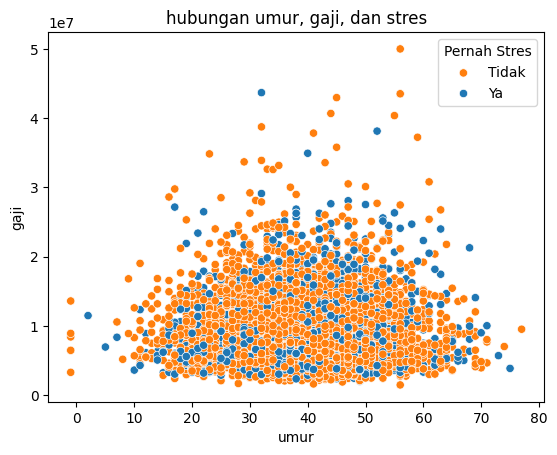

In [ ]:
#abalisis multivariat hubungan antara umur gaji dan stres
sns.scatterplot(x='umur', y='gaji', hue='ever_stress', data=df)
plt.title('hubungan umur, gaji, dan stres')
plt.xlabel('umur')
plt.ylabel('gaji')
plt.legend(title='Pernah Stres', labels=['Tidak', 'Ya'])
plt.show()

#kesimpulan
dari hasil di atas menjelaskan bahwa tidak ada korelasi yg kuat anatara usia, gaji dan stres, itu di karenakan tingkat stres itu berdasarkan faktor pemicu tidak hanya dari segi ekonomi saja.